1. Cargar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer

df_train = pd.read_csv('data/train.csv')
df_test  = pd.read_csv('data/test.csv')

print("✅ Dataset cargado correctamente")
print(f"Train - Filas: {df_train.shape[0]}, Columnas: {df_train.shape[1]}")
print(f"Test  - Filas: {df_test.shape[0]},  Columnas: {df_test.shape[1]}")

✅ Dataset cargado correctamente
Train - Filas: 10886, Columnas: 12
Test  - Filas: 6493,  Columnas: 9


2. Vista general

In [3]:
print("=== PRIMERAS FILAS ===")
display(df_train.head())

print("\n=== TIPOS DE VARIABLES ===")
print(df_train.dtypes)

=== PRIMERAS FILAS ===


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1



=== TIPOS DE VARIABLES ===
datetime          str
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


3. Valores Nulos

In [4]:
nulos = df_train.isnull().sum()
porcentaje = (nulos / len(df_train) * 100).round(2)

missing = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje
}).sort_values('Porcentaje (%)', ascending=False)

print("=== VALORES NULOS ===")
print(missing[missing['Valores nulos'] > 0])
print(f"\nTotal nulos: {df_train.isnull().sum().sum()}")

=== VALORES NULOS ===
Empty DataFrame
Columns: [Valores nulos, Porcentaje (%)]
Index: []

Total nulos: 0


4. Preparar fechas y variables

In [5]:
# Convertir datetime y extraer componentes
df_train['datetime'] = pd.to_datetime(df_train['datetime'])
df_train['hour']     = df_train['datetime'].dt.hour
df_train['day']      = df_train['datetime'].dt.dayofweek
df_train['month']    = df_train['datetime'].dt.month
df_train['year']     = df_train['datetime'].dt.year

print("✅ Variables de fecha extraídas")
df_train[['datetime','hour','day','month','year']].head()

✅ Variables de fecha extraídas


,datetime,hour,day,month,year
0,2011-01-01 00:00:00,0,5,1,2011
1,2011-01-01 01:00:00,1,5,1,2011
2,2011-01-01 02:00:00,2,5,1,2011
3,2011-01-01 03:00:00,3,5,1,2011
4,2011-01-01 04:00:00,4,5,1,2011


5. Imputar nulos con KNN

In [6]:
numericas = df_train.select_dtypes(include='number').columns.tolist()
categoricas = df_train.select_dtypes(include='object').columns.tolist()

# KNN para numéricas
imputer = KNNImputer(n_neighbors=5)
df_num = pd.DataFrame(
    imputer.fit_transform(df_train[numericas]),
    columns=numericas
)

# Moda para categóricas
if categoricas:
    df_cat = df_train[categoricas].fillna(df_train[categoricas].mode().iloc[0])
else:
    df_cat = pd.DataFrame()

df_limpio = pd.concat([df_num, df_cat], axis=1)

print(f"✅ Imputación completada")
print(f"Nulos restantes: {df_limpio.isnull().sum().sum()}")

✅ Imputación completada
Nulos restantes: 0


6. Estadísticas descriptivas

In [7]:
df_limpio.describe().round(2)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,hour,day,month,year
count,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.00,10886.0
mean,2.51,0.03,0.68,1.42,20.23,23.66,61.89,12.80,36.02,155.55,191.57,11.54,3.01,6.52,2011.5
std,1.12,0.17,0.47,0.63,7.79,8.47,19.25,8.16,49.96,151.04,181.14,6.92,2.00,3.44,0.5
min,1.00,0.00,0.00,1.00,0.82,0.76,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,2011.0
25%,2.00,0.00,0.00,1.00,13.94,16.66,47.00,7.00,4.00,36.00,42.00,6.00,1.00,4.00,2011.0
50%,3.00,0.00,1.00,1.00,20.50,24.24,62.00,13.00,17.00,118.00,145.00,12.00,3.00,7.00,2012.0
75%,4.00,0.00,1.00,2.00,26.24,31.06,77.00,17.00,49.00,222.00,284.00,18.00,5.00,10.00,2012.0
max,4.00,1.00,1.00,4.00,41.00,45.46,100.00,57.00,367.00,886.00,977.00,23.00,6.00,12.00,2012.0


7. Demanda por hora del día

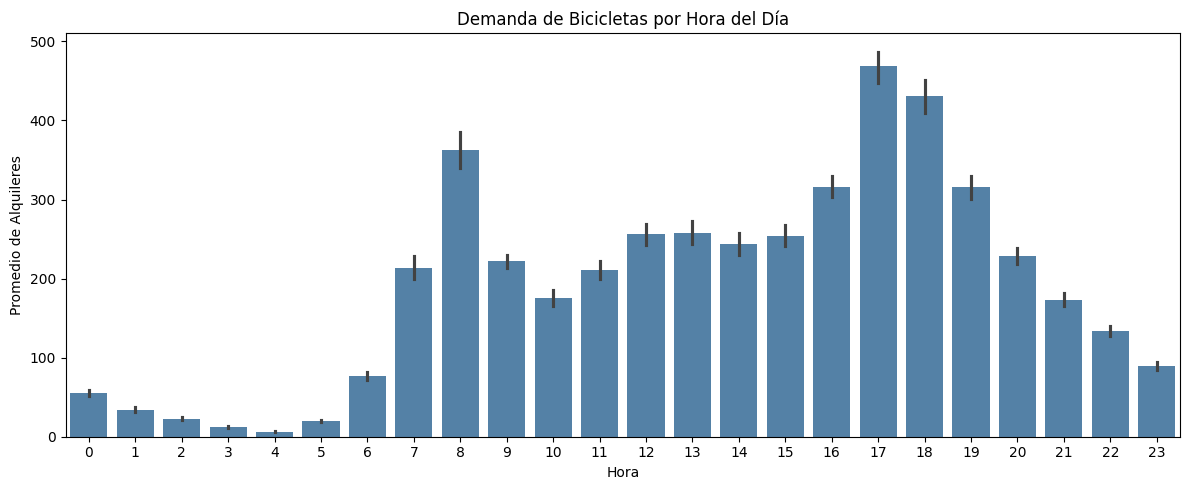

In [8]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df_train, x='hour', y='count', color='steelblue')
plt.title('Demanda de Bicicletas por Hora del Día')
plt.xlabel('Hora')
plt.ylabel('Promedio de Alquileres')
plt.tight_layout()
plt.show()

8. Demanda por temporada

C:\Users\Natalia\AppData\Local\Temp\ipykernel_20108\169494197.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='season_name', y='count', palette='Set2')


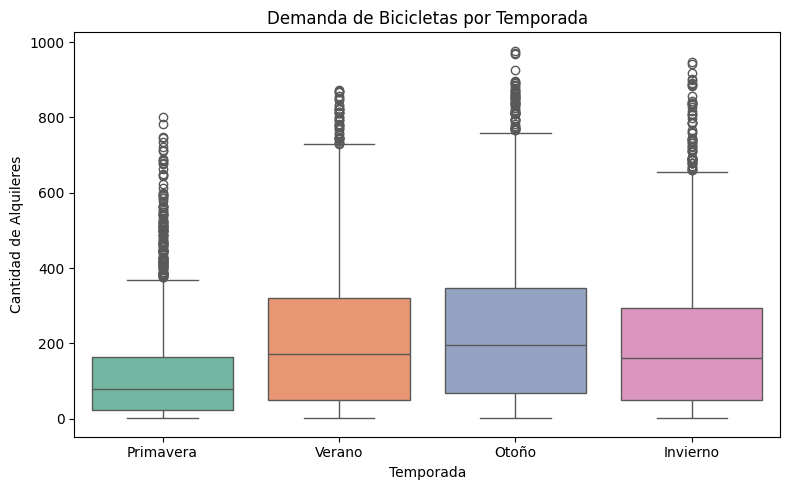

In [9]:
temporadas = {1: 'Primavera', 2: 'Verano', 3: 'Otoño', 4: 'Invierno'}
df_train['season_name'] = df_train['season'].map(temporadas)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_train, x='season_name', y='count', palette='Set2')
plt.title('Demanda de Bicicletas por Temporada')
plt.xlabel('Temporada')
plt.ylabel('Cantidad de Alquileres')
plt.tight_layout()
plt.show()

9. Correlaciones

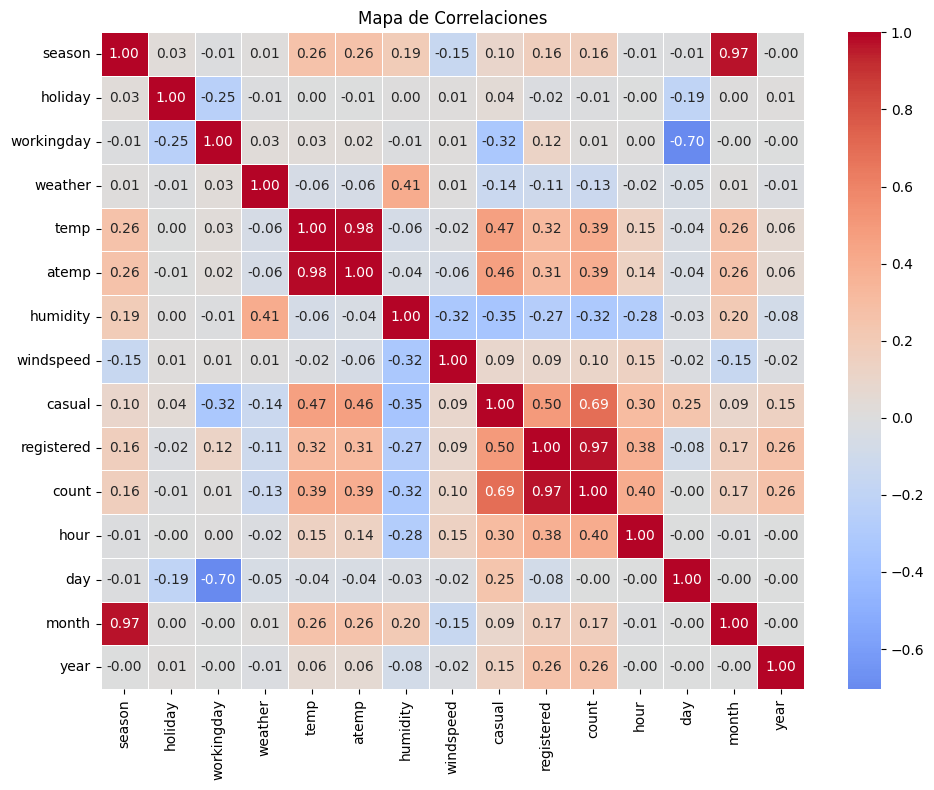

In [10]:
plt.figure(figsize=(10, 8))
corr = df_limpio.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, linewidths=0.5, annot=True, fmt='.2f')
plt.title('Mapa de Correlaciones')
plt.tight_layout()
plt.show()